## Access Animal Satellite Relay Tagging Summary Realtime QC (Parquet)
This Jupyter notebook demonstrates how to access and plot animal_summary_satellite_relay_tagging_realtime_qc data, available as a [Parquet](https://parquet.apache.org) dataset stored on S3.

🔗 More information about the dataset is available [in the AODN metadata catalogue](https://catalogue-imos.aodn.org.au/geonetwork/srv/eng/catalog.search#/metadata/b2548767-514f-4a31-b65e-36bb894382d5).

📌 The source of truth for this notebook is maintained on [GitHub](https://github.com/aodn/aodn_cloud_optimised/tree/main/notebooks/animal_summary_satellite_relay_tagging_realtime_qc.ipynb).


In [1]:
dataset_name = "animal_summary_satellite_relay_tagging_realtime_qc"

## Install/Update packages and Load common functions

In [2]:
import os, requests, importlib.util

open('setup.py', 'w').write(requests.get('https://raw.githubusercontent.com/aodn/aodn_cloud_optimised/main/notebooks/setup.py').text)

spec = importlib.util.spec_from_file_location("setup", "setup.py")
setup = importlib.util.module_from_spec(spec)
spec.loader.exec_module(setup)

setup.install_requirements()
setup.load_dataquery()

✅ Virtual environment already exists, skipping creation.


Using Python 3.12.6 environment at: /home/lbesnard/github_repo/aodn_cloud_optimised/.venv
Resolved 201 packages in 62ms
Checked 201 packages in 2ms


✅ Local version 0.3.23 is up to date (remote: 0.3.18)


In [3]:
from DataQuery import GetAodn

/home/lbesnard/github_repo/aodn_cloud_optimised/notebooks/DataQuery.py:4676: UserWarning: registration of accessor <class 'DataQuery.AODNAccessor'> under name 'aodn' for type <class 'pandas.core.frame.DataFrame'> is overriding a preexisting attribute with the same name.
  @pd.api.extensions.register_dataframe_accessor("aodn")


# Understanding the Dataset

## Understanding Parquet Partitioning

Parquet files can be **partitioned** by one or more columns, which means the data is physically organised into folders based on the values in those columns. This is similar to how databases use indexes to optimise query performance.

Partitioning enables **faster filtering**: when you query data using a partitioned column, only the relevant subset of files needs to be read—improving performance significantly.

For example, if a dataset is partitioned by `"site_code"`, `"timestamp"`, and `"polygon"`, filtering on `"site_code"` allows the system to skip unrelated files entirely.

In this notebook, the `GetAodn` class includes built-in methods to efficiently filter data by **time** and **latitude/longitude** using the **timestamp** and **polygon** partitions. Other partitions can be used for filtering via the `scalar_filter`.

Any filtering on columns that are **not** partitioned can be significantly slower, as all files may need to be scanned. However, the `GetAodn` class provides a `scalar_filter` method that lets you apply these filters at load time—before the data is fully read—helping reduce the size of the resulting DataFrame.

Once the dataset is loaded, further filtering using Pandas is efficient and flexible.

See further below in the notebook for examples of how to filter the data effectively.

To view the actual partition columns for this dataset, run:


In [4]:
aodn = GetAodn()
dname = f'{dataset_name}.parquet'
%time aodn_dataset = aodn.get_dataset(dname)

CPU times: user 6.43 ms, sys: 1.12 ms, total: 7.55 ms
Wall time: 7.15 ms


In [5]:
aodn_dataset.dataset.partitioning.schema

timestamp: int32
polygon: string

## List unique partition values

In [6]:
%%time
unique_partition_value = aodn_dataset.get_unique_partition_values('YOUR_PARTITION_KEY')
print(list(unique_partition_value)[0:2])  # showing a subset only

[]
CPU times: user 639 µs, sys: 0 ns, total: 639 µs
Wall time: 550 µs


## Visualise Spatial Extent of the dataset
This section plots the polygons representing the areas where data is available. It helps to identify and create a bounding box around the regions containing data.

/home/lbesnard/github_repo/aodn_cloud_optimised/.venv/lib/python3.12/site-packages/cartopy/mpl/feature_artist.py:143: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '


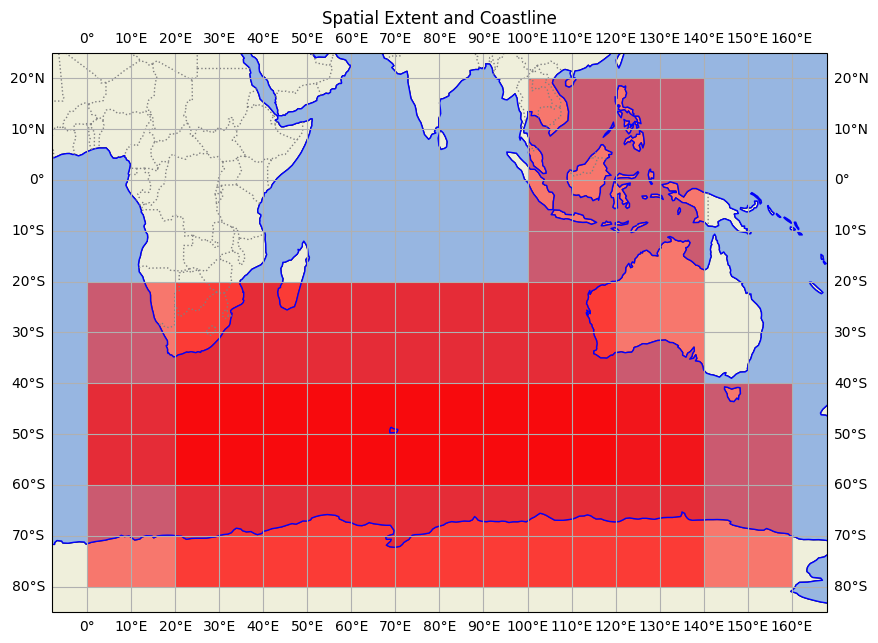

In [7]:
aodn_dataset.plot_spatial_extent()

## Get Temporal Extent of the dataset

Similary to the spatial extent, we're retrieving the minimum and maximum timestamp partition values of the dataset. This is not necessarely accurately representative of the TIME values, as the timestamp partition can be yearly/monthly... but is here to give an idea

In [8]:
%%time
aodn_dataset.get_temporal_extent()

CPU times: user 111 ms, sys: 19.8 ms, total: 131 ms
Wall time: 563 ms


(Timestamp('2025-12-31 12:00:00'), Timestamp('2026-05-31 00:00:00'))

## Read Metadata

For all Parquet datasets, we create a sidecar file named **_common_metadata** in the root of the dataset. This file contains both the dataset-level and variable-level attributes.  
The metadata can be retrieved below as a dictionary, and it will also be included in the pandas DataFrame when using the `get_data` method from the `GetAodn` class.

In [9]:
metadata = aodn_dataset.get_metadata()
metadata

2026-06-03 13:05:47,951 - aodn.GetAodn - INFO - Retrieving metadata for aodn-cloud-optimised/animal_summary_satellite_relay_tagging_realtime_qc.parquet


{'ref': {'type': 'string'},
 'ptt': {'type': 'int32'},
 'cnt': {'type': 'int32'},
 's_date': {'type': 'timestamp[ns]'},
 'e_date': {'type': 'timestamp[ns]'},
 'div_dist': {'type': 'double'},
 'surf_tm': {'type': 'double'},
 'dive_tm': {'type': 'double'},
 'haul_tm': {'type': 'double'},
 'n_cycles': {'type': 'int32'},
 'av_depth': {'type': 'double'},
 'max_depth': {'type': 'double'},
 'cruise_tm': {'type': 'double'},
 'avg_sst': {'type': 'double'},
 'avg_speed': {'type': 'double'},
 'sd_depth': {'type': 'double'},
 'av_dur': {'type': 'int32'},
 'sd_dur': {'type': 'int32'},
 'max_dur': {'type': 'int32'},
 'dp_n_cycles': {'type': 'double'},
 'dp_av_depth': {'type': 'double'},
 'dp_max_depth': {'type': 'double'},
 'dp_avg_speed': {'type': 'double'},
 'dp_sd_depth': {'type': 'double'},
 'dp_av_dur': {'type': 'double'},
 'dp_sd_dur': {'type': 'double'},
 'dp_max_dur': {'type': 'double'},
 'dp_dive_tm': {'type': 'double'},
 'av_surf_dur': {'type': 'double'},
 'sd_surf_dur': {'type': 'double'}

# Data Query and Plot

## Create a TIME and BoundingBox filter

This cell loads a subset of the dataset based on a time range and a spatial bounding box. The result is returned as a pandas DataFrame, and basic information about its structure is displayed.

In [10]:
%%time
# NRT dataset, so we re just showing how to do a time filtering here taking the whole data
df = aodn_dataset.get_data(date_start=aodn_dataset.get_temporal_extent()[0].strftime('%Y-%m-%d'), 
                           date_end=aodn_dataset.get_temporal_extent()[1].strftime('%Y-%m-%d'),
                           )


df.info()

2026-06-03 13:05:49,230 - aodn.GetAodn - INFO - Retrieving metadata for aodn-cloud-optimised/animal_summary_satellite_relay_tagging_realtime_qc.parquet


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12217 entries, 0 to 12216
Data columns (total 61 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   ref              12217 non-null  object        
 1   ptt              12217 non-null  int32         
 2   cnt              12217 non-null  int32         
 3   s_date           12217 non-null  datetime64[ns]
 4   e_date           12217 non-null  datetime64[ns]
 5   div_dist         0 non-null      float64       
 6   surf_tm          12217 non-null  float64       
 7   dive_tm          12217 non-null  float64       
 8   haul_tm          12217 non-null  float64       
 9   n_cycles         12217 non-null  int32         
 10  av_depth         12217 non-null  float64       
 11  max_depth        12217 non-null  float64       
 12  cruise_tm        0 non-null      float64       
 13  avg_sst          0 non-null      float64       
 14  avg_speed        0 non-null      float

In [11]:
df

,ref,ptt,cnt,s_date,e_date,div_dist,surf_tm,dive_tm,haul_tm,n_cycles,...,ssm_lon,ssm_lat,ssm_x,ssm_y,ssm_x_se,ssm_y_se,cid,filename,timestamp,polygon
0,ct189-585-25,35405,8,2025-12-31 12:00:00,2025-12-31 18:00:00,NaN,22.3,46.0,31.7,20,...,70.202214,-49.409602,-2284.435260,3989.206348,0.294487,0.257623,ct189,IMOS_ATF-SATTAG_Location-QC_summary_ct189_nrt.csv,1735689600,0103000000010000000500000000000000000044400000...
1,ct189-585-25,35405,8,2025-12-31 18:00:00,2026-01-01 00:00:00,NaN,74.8,12.6,12.6,22,...,70.252408,-49.402952,-2281.345560,3991.916281,1.099916,0.999183,ct189,IMOS_ATF-SATTAG_Location-QC_summary_ct189_nrt.csv,1735689600,0103000000010000000500000000000000000044400000...
2,ct189-585-25,35405,8,2026-01-01 00:00:00,2026-01-01 06:00:00,NaN,62.0,34.9,3.1,26,...,70.309197,-49.468219,-2273.416224,3987.203226,0.713354,0.586592,ct189,IMOS_ATF-SATTAG_Location-QC_summary_ct189_nrt.csv,1767225600,0103000000010000000500000000000000000044400000...
3,ct189-585-25,35405,8,2026-01-01 06:00:00,2026-01-01 12:00:00,NaN,14.3,85.7,0.0,37,...,70.600025,-49.729758,-2237.377089,3970.708647,0.293542,0.516499,ct189,IMOS_ATF-SATTAG_Location-QC_summary_ct189_nrt.csv,1767225600,0103000000010000000500000000000000000044400000...
4,ct189-593-25,35413,70,2026-01-01 12:00:00,2026-01-01 18:00:00,NaN,33.4,66.6,0.0,81,...,70.176556,-49.352084,-2289.739626,3994.319756,0.012777,0.022348,ct189,IMOS_ATF-SATTAG_Location-QC_summary_ct189_nrt.csv,1767225600,0103000000010000000500000000000000000044400000...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12212,ct190-266-BAT2-20,204698,24,2026-05-30 12:00:00,2026-05-30 18:00:00,NaN,8.0,92.0,0.0,10,...,69.812449,-50.288073,-2257.352710,3880.459284,0.126380,0.442067,ct190,IMOS_ATF-SATTAG_Location-QC_summary_ct190_nrt.csv,1767225600,0103000000010000000500000000000000000044400000...
12213,ct190-266-BAT2-20,204698,24,2026-05-30 18:00:00,2026-05-31 00:00:00,NaN,6.4,93.6,0.0,10,...,69.817291,-50.298187,-2256.402817,3879.580946,0.094754,0.227689,ct190,IMOS_ATF-SATTAG_Location-QC_summary_ct190_nrt.csv,1767225600,0103000000010000000500000000000000000044400000...
12214,ct190-F988-24,265906,3,2026-05-30 18:00:00,2026-05-31 00:00:00,NaN,14.3,85.7,0.0,24,...,102.314840,-64.854662,112.085438,2772.778891,0.432486,0.515393,ct190,IMOS_ATF-SATTAG_Location-QC_summary_ct190_nrt.csv,1767225600,0103000000010000000500000000000000000054400000...
12215,ct190-266-BAT2-20,204698,3,2026-05-31 00:00:00,2026-05-31 06:00:00,NaN,4.8,95.2,0.0,6,...,69.865743,-50.300069,-2253.006018,3881.287959,0.095532,0.295516,ct190,IMOS_ATF-SATTAG_Location-QC_summary_ct190_nrt.csv,1767225600,0103000000010000000500000000000000000044400000...


In [12]:
## Download Subsetted Data as CSV

# This cell downloads the filtered dataset as a ZIP-compressed CSV file.  
# The CSV includes metadata at the top as commented lines, and a `FileLink` object is returned to allow downloading directly from the notebook.


#df.aodn.download_as_csv()

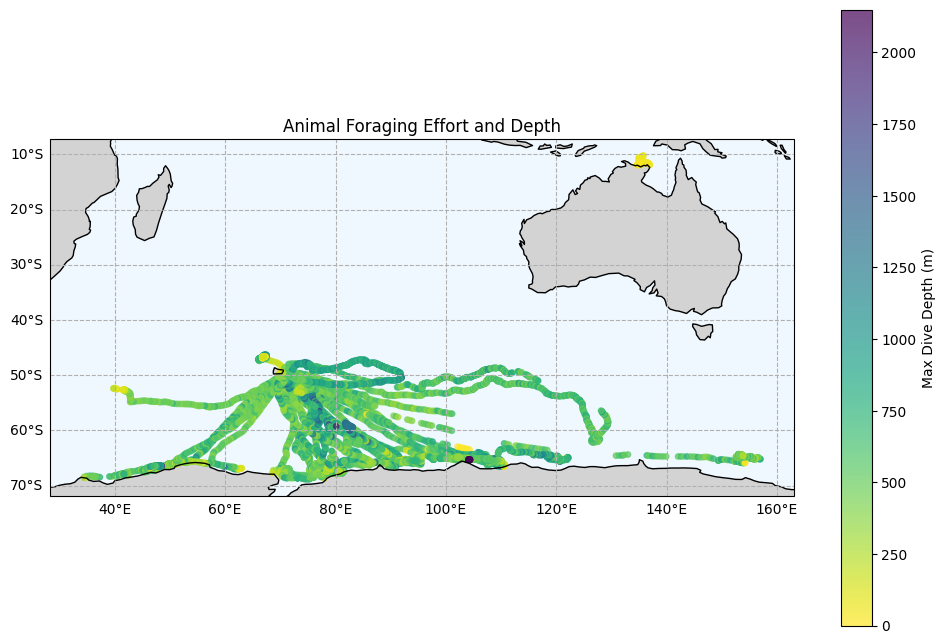

In [13]:
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature

# Set up the figure with a PlateCarree projection (standard lat/lon)
fig = plt.figure(figsize=(12, 8))
ax = plt.axes(projection=ccrs.PlateCarree())

# Add land, ocean, and coastlines
ax.add_feature(cfeature.LAND, facecolor='lightgray')
ax.add_feature(cfeature.OCEAN, facecolor='aliceblue')
ax.add_feature(cfeature.COASTLINE, linewidth=1)

# Plot your behavioral data
# Using 'max_depth' as a proxy for foraging effort
sc = ax.scatter(df['ssm_lon'], df['ssm_lat'], c=df['max_depth'], 
                cmap='viridis_r', s=15, alpha=0.7, 
                transform=ccrs.PlateCarree(), label='Dive Location')

plt.colorbar(sc, label='Max Dive Depth (m)')
plt.title('Animal Foraging Effort and Depth')

# Add gridlines with labels
gl = ax.gridlines(draw_labels=True, linestyle='--')
gl.top_labels = False
gl.right_labels = False

plt.show()